# M1 — FROZEN BioViL-T feature extraction (phase_1)

Extracts one `<image_id>.pt` (`[197, 512]` float16) per CXR — the **exact cache contract** that
`phase_3/src/features.py` loads. row 0 = projected global embedding; rows 1..196 = projected
`[512,14,14]` patch grid flattened `index = y*14+x`.

Run order: **config -> clone -> rclone OAuth -> reference sanity (go/no-go) -> extract (resumable) -> verify**.
Internet ON. GPU ON (T4/P100). The reference cell reproduces a known `docs/*.pt` and asserts
`cosine ~ 1` BEFORE the long run — if it fails, STOP and fix the transform/encoder, don't extract 250k.


## 1. Config


In [1]:
import os
# ===== code from GitHub (cloned next cell) =====
REPO = "/kaggle/working/repo"
PHASE1 = f"{REPO}/phase_1"

# ===== durable cache on Google Drive via YOUR OAuth token (see rclone cell) =====
DRIVE_FOLDER_ID = "1c6AJ3fjsL449kiMK4xiXfnzwzA4gIo0O"   # CHEX-DATA folder id (same as phase_2)
RCLONE_REMOTE   = "dhint:biovilt_features"               # = CHEX-DATA/biovilt_features

# ===== extraction =====
BATCH      = 48      # images per forward (T4 16GB is comfortable)
FLUSH_EVERY= 10000    # push this many .pt to Drive then free local /kaggle/working
LIMIT      = 0       # >0 = stop after N new images (smoke test); 0 = all

for k, v in dict(REPO=REPO, PHASE1=PHASE1, DRIVE_FOLDER_ID=DRIVE_FOLDER_ID,
                 RCLONE_REMOTE=RCLONE_REMOTE, BATCH=BATCH, FLUSH_EVERY=FLUSH_EVERY,
                 LIMIT=LIMIT).items():
    os.environ[k] = str(v)
print("remote =", RCLONE_REMOTE, "| BATCH =", BATCH, "| LIMIT =", LIMIT)

remote = dhint:biovilt_features | BATCH = 48 | LIMIT = 0


In [2]:
# --- get the code from GitHub. Internet ON. ---
!rm -rf /kaggle/working/repo && git clone -q https://github.com/hiennguyendang/phase_2_3_4_5 /kaggle/working/repo
!ls /kaggle/working/repo/phase_1/scripts

1-build_worklist.py  2-extract_features.py  3-verify_features.py


## 2. Resolve input mounts (auto-detect)
`data/` is gitignored, so the manifest / pairs / labels / images come from **Kaggle datasets**,
not the repo clone. Add them to the notebook: `nguynnghin/mimic-cxr-448`, and the m3/m4 label
datasets that carry `manifest.jsonl`, `m3_pairs.jsonl`, `boxes.npy`.


In [3]:
import glob, os
from pathlib import Path

# Dataset của bạn ở datasets/nguynnghin/<slug>; fallback về mount cổ điển /kaggle/input/<slug>.
# Dò có mục tiêu + lazy (iglob) -> KHÔNG quét đệ quy 377k ảnh.
BASES = ['/kaggle/input/datasets/nguynnghin', '/kaggle/input']

def resolve_file(slug, name):
    for b in BASES:                                   # trực tiếp, rồi 1 lớp Kaggle bọc thêm
        for pat in (f'{b}/{slug}/{name}', f'{b}/{slug}/*/{name}'):
            hit = next(iter(glob.iglob(pat)), None)
            if hit:
                return hit
    for b in BASES:                                   # cùng lắm: chỉ tìm bên trong slug đó
        hit = next(iter(glob.iglob(f'{b}/{slug}/**/{name}', recursive=True)), None)
        if hit:
            return hit
    return None

def resolve_images(slug):
    for b in BASES:                                   # thư mục chứa trực tiếp p10/p10000032/*.jpg
        for cand in [f'{b}/{slug}'] + sorted(glob.glob(f'{b}/{slug}/*')):
            if os.path.isdir(cand) and next(iter(glob.iglob(f'{cand}/p*/p*/*.jpg')), None):
                return cand
    return None

IMAGES_ROOT = resolve_images('mimic-cxr-448')
MANIFEST    = resolve_file('m3-labels', 'manifest.jsonl')
BOXES       = resolve_file('m3-labels', 'boxes.npy')
PAIRS       = resolve_file('m4-labels', 'm3_pairs.jsonl')
LABELS_DIR  = str(Path(BOXES).parent) if BOXES else ''
for k, v in dict(IMAGES_ROOT=IMAGES_ROOT, MANIFEST=MANIFEST, PAIRS=PAIRS,
                 BOXES=BOXES, LABELS_DIR=LABELS_DIR).items():
    os.environ[k] = str(v) if v else ''
    print(f'{k:12} = {v}')
assert IMAGES_ROOT and MANIFEST and PAIRS and BOXES, \
    'not found — check slug (mimic-cxr-448 / m3-labels / m4-labels) đã attach chưa'

IMAGES_ROOT  = /kaggle/input/datasets/nguynnghin/mimic-cxr-448/mimic-cxr-448
MANIFEST     = /kaggle/input/datasets/nguynnghin/m3-labels/manifest.jsonl
PAIRS        = /kaggle/input/datasets/nguynnghin/m4-labels/m3_pairs.jsonl
BOXES        = /kaggle/input/datasets/nguynnghin/m3-labels/boxes.npy
LABELS_DIR   = /kaggle/input/datasets/nguynnghin/m3-labels


## 3. rclone + Drive auth (YOUR OAuth token)
Install rclone, then configure remote `dhint` from the Kaggle Secret `GDRIVE_TOKEN`
(`rclone authorize "drive"`). **Not** a service account — an SA has no My-Drive quota and 403s
on upload. Optional `GDRIVE_CLIENT_ID/SECRET` give a private query quota for the many small files.


In [4]:
%%bash
set -e
if ! command -v rclone >/dev/null 2>&1; then
  cd /kaggle/working && curl -sLO https://downloads.rclone.org/rclone-current-linux-amd64.zip
  unzip -q -o rclone-current-linux-amd64.zip && cp rclone-*-linux-amd64/rclone /usr/local/bin/ && chmod +x /usr/local/bin/rclone
fi
rclone version | head -1

rclone v1.74.3


In [5]:
import os
# Drive remote 'dhint' via YOUR OAuth token (NOT a service account: SA has no storage quota and
# 403s on upload to My Drive). Token = `rclone authorize "drive"` -> Kaggle Secret GDRIVE_TOKEN.
# Graceful: if missing/unwritable, extraction still runs but WITHOUT Drive sync/resume.
SYNC_OK = "0"
try:
    from kaggle_secrets import UserSecretsClient
    sec = UserSecretsClient()
    token = sec.get_secret("GDRIVE_TOKEN").strip()
    os.environ["RCLONE_CONFIG_DHINT_TYPE"] = "drive"
    os.environ["RCLONE_CONFIG_DHINT_TOKEN"] = token
    os.environ["RCLONE_CONFIG_DHINT_SCOPE"] = "drive"
    os.environ["RCLONE_CONFIG_DHINT_ROOT_FOLDER_ID"] = os.environ["DRIVE_FOLDER_ID"]
    os.environ.pop("RCLONE_CONFIG_DHINT_SERVICE_ACCOUNT_FILE", None)  # drop stale SA
    for k_sec, k_env in [('GDRIVE_CLIENT_ID', 'RCLONE_CONFIG_DHINT_CLIENT_ID'),
                         ('GDRIVE_CLIENT_SECRET', 'RCLONE_CONFIG_DHINT_CLIENT_SECRET')]:
        try:
            os.environ[k_env] = sec.get_secret(k_sec).strip()
        except Exception:
            pass
    using_own = 'own client' if os.environ.get('RCLONE_CONFIG_DHINT_CLIENT_ID') else 'rclone shared client'
    remote = os.environ["RCLONE_REMOTE"]
    if os.system('rclone mkdir "%s"' % remote) == 0 and \
       os.system('echo ok | rclone rcat "%s/_write_test.txt"' % remote) == 0:
        SYNC_OK = "1"
        os.system('rclone delete "%s/_write_test.txt" 2>/dev/null' % remote)
        print(f"remote OK (OAuth, write verified, {using_own}) ->", remote)
    else:
        print("[WARN] Drive write FAILED -> check GDRIVE_TOKEN (write scope) + DRIVE_FOLDER_ID")
except Exception as e:
    print("[WARN] GDRIVE_TOKEN secret not set -> NO Drive sync:", e)
os.environ["SYNC_OK"] = SYNC_OK
print("SYNC_OK =", SYNC_OK)

[WARN] Drive write FAILED -> check GDRIVE_TOKEN (write scope) + DRIVE_FOLDER_ID
SYNC_OK = 0


2026/07/01 06:35:38 NOTICE: Config file "/root/.config/rclone/rclone.conf" not found - using defaults
2026/07/01 06:35:38 ERROR : Attempt 1/3 failed with 1 errors and: couldn't list directory: Get "https://www.googleapis.com/drive/v3/files?alt=json&fields=files%28id%2Cname%2Csize%2Cmd5Checksum%2Csha1Checksum%2Csha256Checksum%2Ctrashed%2CexplicitlyTrashed%2CmodifiedTime%2CcreatedTime%2CmimeType%2Cparents%2CwebViewLink%2CshortcutDetails%2CexportLinks%2CresourceKey%29%2CnextPageToken%2CincompleteSearch&includeItemsFromAllDrives=true&pageSize=1000&prettyPrint=false&q=trashed%3Dfalse+and+%28%271c6AJ3fjsL449kiMK4xiXfnzwzA4gIo0O%27+in+parents%29+and+%28name%3D%27biovilt_features%27%29+and+%28mimeType%3D%27application%2Fvnd.google-apps.folder%27+or+mimeType%3D%27application%2Fvnd.google-apps.shortcut%27%29&supportsAllDrives=true": couldn't fetch token: invalid_client: if you're using your own client id/secret, make sure they're properly set up following the docs
2026/07/01 06:35:38 ERROR : Att

## 4. Install BioViL-T (`hi-ml-multimodal`)


In [6]:
!pip install -q hi-ml-multimodal 2>/dev/null || pip install -q git+https://github.com/microsoft/hi-ml.git#subdirectory=hi-ml-multimodal
import health_multimodal, torch
print("health_multimodal", health_multimodal.__version__ if hasattr(health_multimodal, "__version__") else "ok",
      "| torch", torch.__version__, "| cuda", torch.cuda.is_available())

health_multimodal 0.2.2 | torch 2.10.0+cu128 | cuda True


## 5. Build the worklist (manifest U prior_image_id)


In [7]:
!python $PHASE1/scripts/1-build_worklist.py \
    --images-root $IMAGES_ROOT --manifest $MANIFEST --pairs $PAIRS \
    --out /kaggle/working/worklist.jsonl

image_ids to extract: 252,290  (manifest U prior; from manifest.jsonl + m3_pairs.jsonl)
[info] sharded guess missed MIMIC_p12542274_s55409636_be4e3efa-36b2e563-0b98fc87-e5e7988e-7efbe2fc; walked root (377,105 images)
[DONE] worklist -> /kaggle/working/worklist.jsonl
  resolved : 252,287
  missing  : 3  e.g. ['MIMIC_p12542274_s55409636_be4e3efa-36b2e563-0b98fc87-e5e7988e-7efbe2fc', 'MIMIC_p18052701_s55016092_5e11a519-d93ce55f-e0cf2f24-e3515d37-46c56eba', 'MIMIC_p18052701_s55016092_f26b6bc7-bef5e55d-c67fea50-a0c99036-d55931f6']
  (missing = image_id had no jpg under --images-root; check the mount / --index-walk)


## 6. Reference sanity — GO / NO-GO (run this FIRST)
Reproduce the bundled `docs/<id>.pt` with the live encoder and assert `cosine ~ 1`. This proves the
**model variant + preprocessing + flatten order** all match the existing collaborator cache. If it
FAILS, flip `TRANSFORM_MODE` in `phase_1/src/config.py` to `resize_crop` (or check the encoder) and
re-run — do **not** extract 250k images until this passes.


In [8]:
import glob, os
os.environ['REF'] = glob.glob(f'{PHASE1}/reference/MIMIC_*.pt')[0]
print('reference =', os.environ['REF'])
!python $PHASE1/scripts/3-verify_features.py \
    --reference $REF --images-root $IMAGES_ROOT \
    --features-root /kaggle/working/features --manifest $MANIFEST --pairs $PAIRS \
    --labels-dir $LABELS_DIR --region 'right lung' --align-png /kaggle/working/alignment_check.png

reference = /kaggle/working/repo/phase_1/reference/MIMIC_p10000032_s50414267_02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.pt
manifest ids 212,555 | prior ids 190,892

[1/2 FAIL] no .pt under /kaggle/working/features
[3] coverage: manifest 0/212,555 (0.0%) | priors 0/190,892
    missing 212,555 manifest features, e.g. ['MIMIC_p10000032_s50414267_02aa804e-bde0afdd-112c0b34-7bc16630-4e384014', 'MIMIC_p10000032_s53189527_2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab', 'MIMIC_p10000032_s53911762_68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714']
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
100%|████████████████████████████████████████| 110M/110M [00:06<00:00, 16.2MB/s]
[4 FAIL] shape (197, 128) != reference (197, 512)
[5] alignment: 'right lung' on MIMIC_p10000032_s5041

In [9]:
import glob, os, sys, torch
sys.path.insert(0, '/kaggle/working/repo/phase_1/src')
import biovilt

jpg = next(iter(glob.iglob(os.environ['IMAGES_ROOT'] + '/p*/p*/*.jpg')))
m = biovilt.load_encoder('cuda')
img = biovilt.load_image(jpg).unsqueeze(0).to('cuda')
with torch.no_grad():
    out = m(img)

print("output type:", type(out).__name__)
fields = getattr(out, '_fields', None) or [a for a in dir(out) if not a.startswith('_')]
for f in fields:
    v = getattr(out, f, None)
    if torch.is_tensor(v):
        print(f"  {f:34} {tuple(v.shape)}")

ref = torch.load(glob.glob('/kaggle/working/repo/phase_1/reference/MIMIC_*.pt')[0],
                 map_location='cpu').float()
print("reference .pt:", tuple(ref.shape), "-> C =", ref.shape[1])

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


output type: ImageModelOutput
  img_embedding                      (1, 512)
  patch_embeddings                   (1, 512, 14, 14)
  projected_global_embedding         (1, 128)
  projected_patch_embeddings         (1, 128, 14, 14)
reference .pt: (197, 512) -> C = 512


In [10]:
!df -h /kaggle/working
print("FLUSH_EVERY =", os.environ.get("FLUSH_EVERY"), "| BATCH =", os.environ.get("BATCH"))

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  367M   20G   2% /kaggle/working
FLUSH_EVERY = 10000 | BATCH = 48


## 7. Extract (resumable)
Writes `<id>.pt`, flushes to Drive every `FLUSH_EVERY`, deletes local to free space. Re-run after a
session dies — it skips image_ids already on Drive (`rclone lsf`) or staged locally.


In [11]:
!python $PHASE1/scripts/2-extract_features.py \
    --worklist /kaggle/working/worklist.jsonl --out-dir /kaggle/working/features \
    --remote $RCLONE_REMOTE --device cuda --batch $BATCH --flush-every $FLUSH_EVERY --limit $LIMIT

worklist 252,287 | already done 0 | to extract 252,287
loading FROZEN BioViL-T encoder on cuda ...
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
feature dim C = 128  (expected 512; transform=stretch448)
[WARN] C=128 != config.FEAT_DIM=512. The phase_3 loader auto-detects C, but the WHOLE cache must share one C — verify against the reference.
  [960/252,287] extracted
  [1,920/252,287] extracted
  [2,880/252,287] extracted
  [3,840/252,287] extracted
  [4,800/252,287] extracted
  [5,760/252,287] extracted
  [6,720/252,287] extracted
  [7,680/252,287] extracted
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 977, in save
    _save(
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.

## 8. Verify
Structure / naming / coverage + the alignment overlay. (Coverage counts the **local** staging dir;
for full-cache coverage, `rclone copy $RCLONE_REMOTE /kaggle/working/features` a sample back first.)


manifest ids 212,555 | prior ids 190,892

structure: sampling 2000/8,477 files
[1 PASS] structure: 2,000 checked | C=[128] | bad_shape=0 bad_dtype=0 nonfinite=0
        note: C=[128] (config.FEAT_DIM=512); phase_3 auto-detects but the whole cache must share ONE C.
[2 PASS] naming: 0 stems not in manifest+priors
[3] coverage: manifest 7,149/212,555 (3.4%) | priors 6,437/190,892
    missing 205,406 manifest features, e.g. ['MIMIC_p10337403_s59371701_372d340d-50d1e233-42b99cfb-addb45f4-c937bfa1', 'MIMIC_p10337407_s53460884_80bfd410-b6992b5b-05f75ca2-ae0cc278-5ce81894', 'MIMIC_p10337761_s51156352_26a053c4-d5542019-07be9681-06d3187f-83317305']
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[4 FAIL] shape (197, 128) != reference (197, 512)
[5] alignment: 'right lung' 

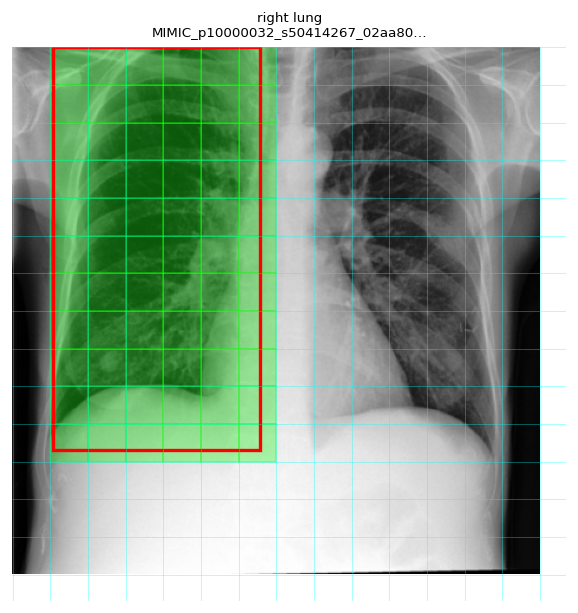

In [12]:
!python $PHASE1/scripts/3-verify_features.py \
    --features-root /kaggle/working/features --labels-dir $LABELS_DIR \
    --images-root $IMAGES_ROOT --manifest $MANIFEST --pairs $PAIRS \
    --region 'right lung' --align-png /kaggle/working/alignment_check.png
from IPython.display import Image as IPImage
IPImage('/kaggle/working/alignment_check.png')